In [1]:
#Deep Graph Anomaly Detection with Contrastive Learning

In [2]:
import torch
torch.mps.empty_cache()

In [3]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [4]:
file = h5py.File("../quark-gluon_data-set_n139306.hdf5", "r")
print(list(file.keys()))

['X_jets', 'm0', 'pt', 'y']


In [5]:
images = file["X_jets"][:20000]   # load only 20k samples
labels = file["y"][:20000]

print(images.shape)

(20000, 125, 125, 3)


In [6]:
images = np.transpose(images, (0,3,1,2))

print(images.shape)

(20000, 3, 125, 125)


In [7]:
images = images / np.max(images)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

In [9]:
def image_to_pointcloud(image, max_nodes = 10000):

    nodes = []

    for c in range(3):
        for i in range(125):
            for j in range(125):
                val = image[c,i,j]
                if val > 0:
                    x = i / 125
                    y = j / 125
                    nodes.append([x, y, val, c])

    nodes= np.array(nodes)
    if len(nodes) > max_nodes:
        idx = np.argsort(nodes[:,2])[-max_nodes:]
        nodes = nodes[idx]

    return nodes

In [10]:
from sklearn.neighbors import NearestNeighbors

def build_edges(nodes, k=5):

    coords = nodes[:, :2]

    nbrs = NearestNeighbors(n_neighbors=k).fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    edges = []

    for i in range(len(nodes)):
        for j in indices[i]:
            edges.append([i, j])

    edge_index = torch.tensor(edges).t().contiguous()

    return edge_index

In [11]:
from torch_geometric.data import Data

def create_graph(image, label):
    nodes = image_to_pointcloud(image)
    x = torch.tensor(nodes, dtype=torch.float)
    edge_index = build_edges(nodes)
    y = torch.tensor([int(label)], dtype=torch.long) 

    return Data(x=x, edge_index=edge_index, y=y)

In [12]:
graphs = []

for i in range(1000):
    graph = create_graph(images[i], labels[i])
    graphs.append(graph)

In [13]:
train_graphs, test_graphs = train_test_split(
    graphs, test_size=0.2, random_state=42
)

In [14]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=4, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=4)

In [15]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GraphEncoder(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(4, 64)
        self.conv2 = GCNConv(64, 64)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return x

In [16]:
class ContrastiveModel(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = GraphEncoder()
        self.projector = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 16)
        )

    def forward(self, data):
        h = self.encoder(data)
        z = self.projector(h)
        return z

In [17]:
def augment_graph(data):
    x = data.x.clone()
    noise = torch.randn_like(x) * 0.01
    data_aug = data.clone()
    data_aug.x = x + noise
    return data_aug

In [18]:
def contrastive_loss(z1, z2):
    return 1 - torch.cosine_similarity(z1, z2).mean()

In [19]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ContrastiveModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [20]:
for epoch in range(10):

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        aug1 = augment_graph(data)
        aug2 = augment_graph(data)

        z1 = model(aug1)
        z2 = model(aug2)

        loss = contrastive_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 1.6093254089355469e-06
Epoch: 1 Loss: 1.0728836059570312e-06
Epoch: 2 Loss: 8.344650268554688e-07
Epoch: 3 Loss: 5.960464477539062e-07
Epoch: 4 Loss: 8.344650268554688e-07
Epoch: 5 Loss: 9.5367431640625e-07
Epoch: 6 Loss: 8.940696716308594e-07
Epoch: 7 Loss: 1.6093254089355469e-06
Epoch: 8 Loss: 1.2516975402832031e-06
Epoch: 9 Loss: 1.3113021850585938e-06


In [21]:
def get_embeddings(loader):

    model.eval()

    embeddings = []
    labels_list = []

    for data in loader:

        data = data.to(device)

        h = model.encoder(data)

        embeddings.append(h.cpu())
        labels_list.append(data.y.cpu())

    return torch.cat(embeddings), torch.cat(labels_list)

In [27]:
train_emb, train_labels = get_embeddings(train_loader)
test_emb, test_labels = get_embeddings(test_loader)

In [28]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(train_emb.detach().numpy(), train_labels.detach().numpy())
pred = clf.predict(test_emb.detach().numpy())

In [29]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, pred)
print("accuracy:", accuracy)

accuracy: 0.505


In [30]:
from sklearn.metrics import roc_auc_score
probs = clf.predict_proba(test_emb.detach().cpu().numpy())[:,1]
auc = roc_auc_score(test_labels, probs)
print("ROC AUC:", auc)

ROC AUC: 0.5470806954074966


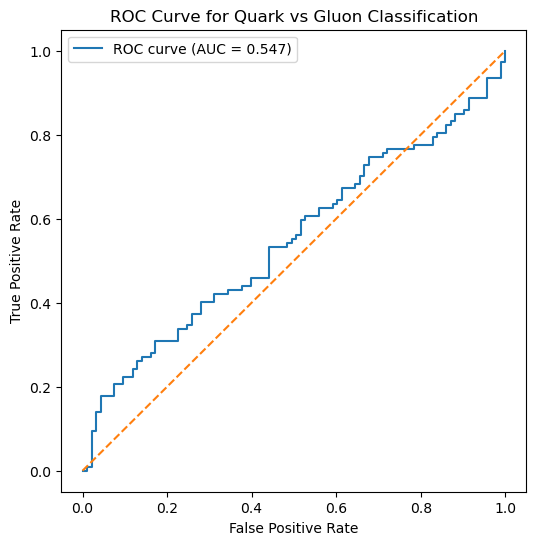

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_test = test_labels.detach().cpu().numpy()
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC curve (AUC = %.3f)" % auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Quark vs Gluon Classification")
plt.legend()

plt.show()